# Pupil-plane amplitude aberrations: are they degenerate with `primary_opd`?

At the best fit of `calibrator-fit-bootstrap.ipynb` we add a **Fourier-basis log-amplitude screen**
(`primary_amp`, `n_new` x `n_new` modes) just after `primary_opd`, i.e. upstream of the occulter, and ask
how much *new* information the data hold about it, given the 45x45 `primary_opd` and all the other
fitted parameters. The tool is the Gauss-Newton (Fisher) Hessian of the whitened residuals.

In [1]:
import sys
sys.path.insert(0, '..')

In [2]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import interpax as ipx

## Settings and data

In [3]:
wf_wid = 512
wid = 80
oversample = 4

nwavels = 3
npoly=1

n_modes = 45
n_zernikes = 30

# Fourier modes per axis of the new amplitude block (one knob: 45 matches primary_opd)
n_new = 45
# Jacobian columns per vmap batch (memory vs speed)
batch_size = 2

resolved_wid = 1

optics = NICMOSCoronagraph(wf_wid, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))

ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
flatdir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

exposures_single = [
    exposure_from_file(ddir + 'n8jv53xsq_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F187N"), crop=wid, extra_bad=np.load("bad_map.npy"), flatcorr=flatdir),
]

ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


## Model with a pupil-plane amplitude screen

`FourierAmplitude` multiplies the field by `exp(log-amplitude)`, with the log-amplitude a real Fourier series.
It sits right after `primary_opd`, so it is applied in the wavelength-independent stage before the occulter.
That stage runs on `_AmpOpd`, which supports `*` for amplitudes, so the inherited `propagate` works unchanged.
The layer list is the one in `apertures.NICMOSCoronagraph` (without the optional turboklip layer) plus the new layer.

In [4]:
class FourierAmplitude(dl.FourierBasis):
    """Real Fourier-series log-amplitude screen: field *= exp(sum of coefficients x Fourier modes)."""

    def __call__(self, wavefront):
        return wavefront * np.exp(self.eval_basis())


class NICMOSCoronagraphAmp(NICMOSCoronagraph):

    def __init__(self, wf_npixels, psf_npixels, oversample, n_modes=12, n_zernikes=1., n_new=45, wl_batch=None, remat=False):
        diameter = 3.
        layers = [
            ("primary",HSTMainAperture(transformation=dl.CoordTransform(rotation=np.pi/4), softening=5)),

            ("primary_tilt", dl.Tilt(angles=(0.,0.))),

            ("primary_opd", dl.FourierBasis(wf_npixels, n_modes=n_modes)),

            # New: amplitude screen, upstream of the occulter like primary_opd
            ("primary_amp", FourierAmplitude(wf_npixels, n_modes=n_new)),

            ("primary_low", ScanAberratedAperture(
                    dl.layers.CircularAperture(1.2,transformation=dl.CoordTransform(translation=np.zeros(2)),),
                    noll_inds=np.arange(4,4+n_zernikes),
                    coefficients = np.zeros(n_zernikes),
                )),

            ("flip", dl.Flip(axes=(0,1))),

            ("occulter", SoummerFastObstruction([
                ("prop1", dl.MFT(256, focal_length=24*2.4, pixel_scale=1.5e-6)),
                ("occulter", CLIMBOcculter(dlu.arcsec2rad(0.3)*24*2.4, np.zeros(1), np.zeros(1))),
                ("prop1", dl.MFT(wf_npixels, focal_length=24*2.4, pixel_scale=diameter/wf_npixels)),
            ])),

            ("cold_mask",   NIC2ColdMask(transformation=dl.CoordTransform(translation=np.asarray((-0.05,-0.05)),rotation=np.pi/4, compression=np.asarray([1.,1.])), softening=5, normalise=False)),

            ("cold_mask_opd", ScanAberratedAperture(
                    dl.layers.CircularAperture(1.2, transformation=dl.CoordTransform(translation=np.asarray((-0.05, -0.05)))),
                    noll_inds=np.arange(4,20),
                    coefficients = np.zeros(1),
                )),

            ("cold_mask_tilt", dl.Tilt(angles=(0.,0.))),

            ("prop1", dl.MFT(psf_npixels*oversample, focal_length=45.7*2.4, pixel_scale=40e-6/oversample)),
        ]

        dl.LayeredOpticalSystem.__init__(self, wf_npixels, diameter, layers)
        self.wl_batch = wl_batch
        self.remat = bool(remat)

optics_amp = NICMOSCoronagraphAmp(wf_wid, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes, n_new=n_new)

## Fit class

`primary_amp` is stored in "nm-equivalent" units: a coefficient of 1 changes the field by the same fraction
as 1 nm of OPD changes its phase, `2 pi 1e-9 / lambda_c` (lambda_c the filter's mean wavelength). That gives
`primary_opd` and `primary_amp` a common metric in the joint Hessian. The piston is zeroed as for `primary_opd`.

In [5]:
class AmplitudeFit(SinglePointFit):
    PARAM_KEYS = SinglePointFit.PARAM_KEYS | {"primary_amp": "global"}

    def update_optics(self, model, exposure):
        optics = super().update_optics(model, exposure)

        if "primary_amp" in model.params.keys():
            spec = self.source.spectrum
            wl_c = np.sum(spec.wavelengths*spec.filt_weights)/np.sum(spec.filt_weights)
            c = model.get(self.map_param(exposure, "primary_amp")).at[0,0].set(0.)
            optics = optics.set("primary_amp.coefficients", c*2*np.pi*1e-9/wl_c)

        return optics

## Best fit

Parameters are those of the bootstrap notebook's initial setup, overwritten by its final `params_history[-1]`
(saved in `params.npy`), plus `primary_amp = 0`.

In [6]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},
    "primary_rot": {},
    "primary_shear": {},

    "bias": {},
    "occulter_radius": 0.8,
    "occulter_coeffs": np.zeros(4)+1e-3,
    "fnumber": 45.7,
    "anisotropy": 1.+1e-5,

    "outer_radius": 1.2*0.9768,
    "secondary_radius": 0.365*1.2,
    "spider_width": 0.072*1.2,
    "primary_spider": 0.0256,
    "primary_secondary": 0.330*1.2,
    "primary_outer": 1.2,
    "primary_pad": 0.065*1.2,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*210)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.05, -0.75])*0.075
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([
        np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44),
        np.array(exp.hdr["TARSIAFX"],dtype=float) - (256-181),
    ])*0.075

    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.zeros(16).at[0].set(120.)

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.array([13.,10.])
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 3.2
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -0.6
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.06,-0.06])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.

# Final params_history[-1] of calibrator-fit-bootstrap.ipynb (the saved best fit)
params = params | numpy.load("params.npy", allow_pickle=True).item()
params["primary_opd"] = {k: v[:n_modes, :n_modes] for k, v in params["primary_opd"].items()}

# New block, starting at zero
fit = AmplitudeFit(spectrum_basis, "F187N")
exposures = [exp.set("fit", fit) for exp in exposures_single]
params["primary_amp"] = {fit.get_key(exposures[0], "primary_amp"): np.zeros((n_new, n_new))}

model = set_array(NICMOSModel(exposures, params, optics_amp, detector))
params = ModelParams(params)
exp = exposures[0]

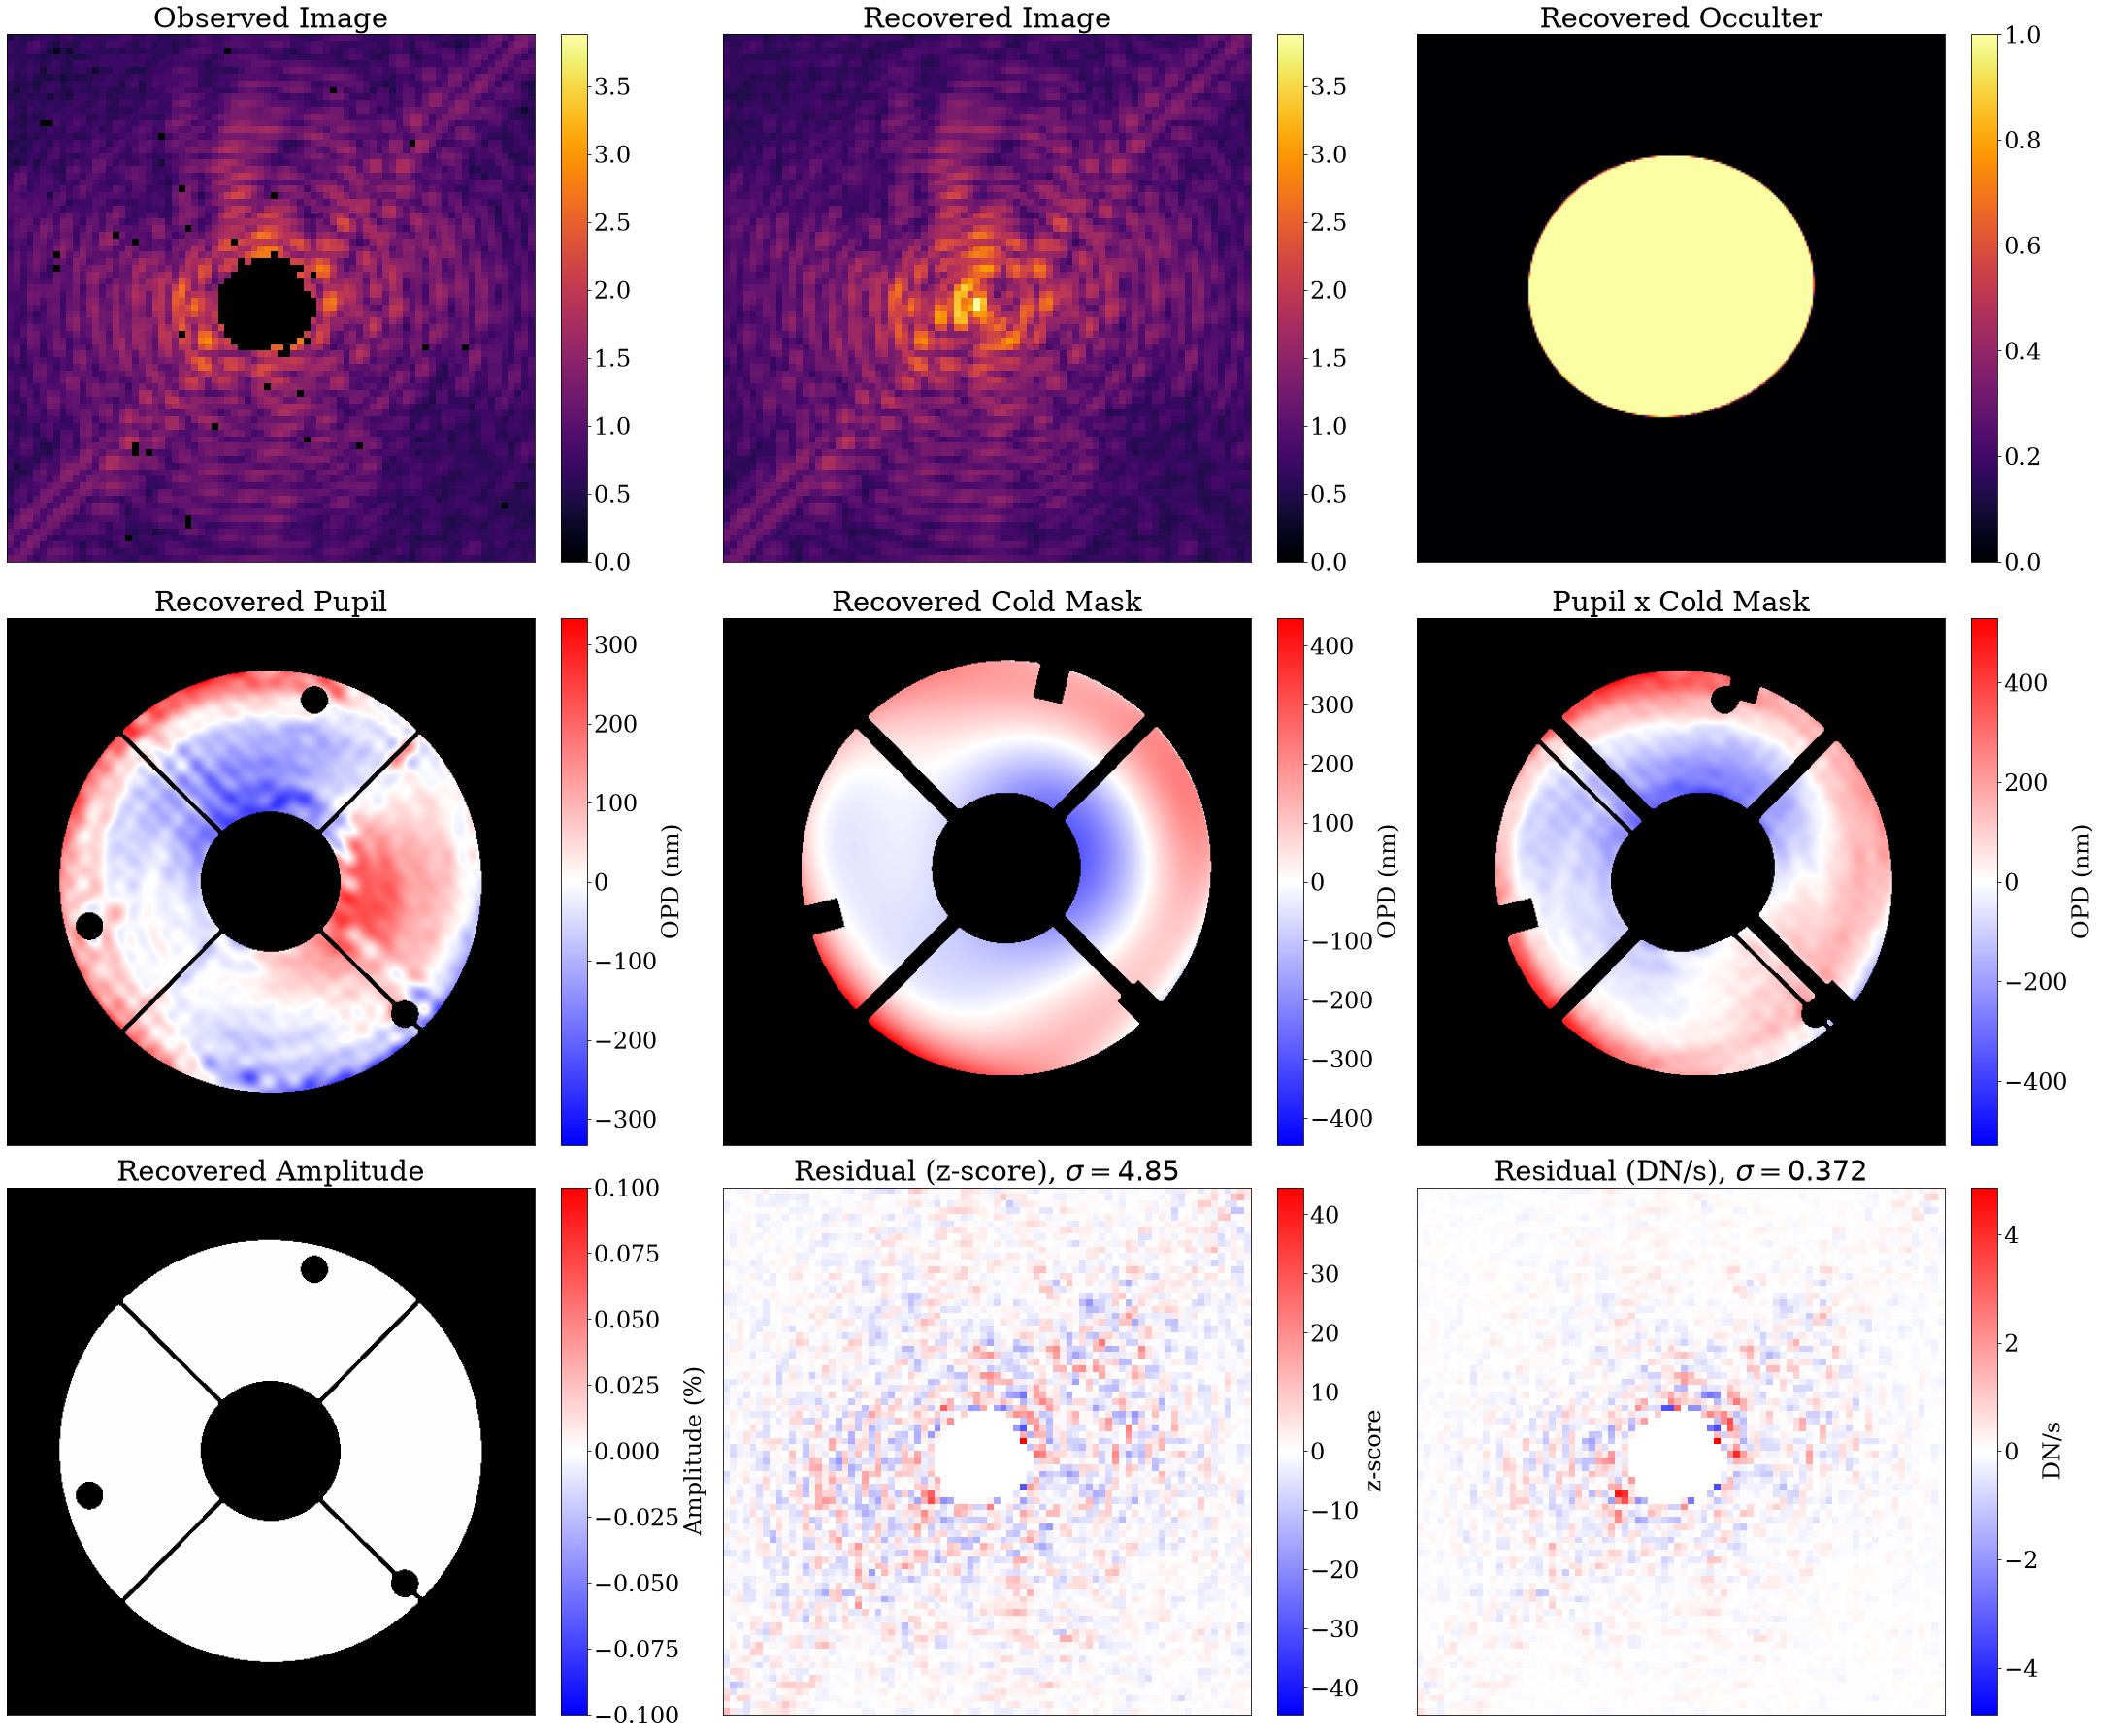

In [7]:
plot_comparison_detailed(model, params, exposures, percentile=100, wf_size=wf_wid)

### Checks

With zero coefficients the new model must reproduce `NICMOSCoronagraph` exactly, and a non-zero
coefficient must change the image.

In [8]:
# Reference: the original optics and fit class, same parameters without primary_amp
ref_params = {k: v for k, v in params.params.items() if k != "primary_amp"}
ref_model = set_array(NICMOSModel(exposures_single, ref_params, optics, detector))
ref_image = exposures_single[0].fit(ref_model, exposures_single[0])
new_image = exp.fit(model, exp)
print("zero coefficients, bit-for-bit equal:", bool(numpy.array_equal(ref_image, new_image)))

key = fit.get_key(exp, "primary_amp")
poked = model.set(f"params.primary_amp.{key}", np.zeros((n_new, n_new)).at[3, 2].set(5.))
poked_image = exp.fit(poked, exp)
print("5 nm-equivalent poke changes the image: max |dI| =", float(np.nanmax(np.abs(poked_image - new_image))), "DN/s")

zero coefficients, bit-for-bit equal: True
5 nm-equivalent poke changes the image: max |dI| = 3.5970047620419336 DN/s


## Jacobian

One forward-mode column per element of `primary_opd` (all 45x45), `primary_amp` (all `n_new`x`n_new`) and every
other parameter optimised in the bootstrap's final stage. `model_jacobian` returns NaN at bad pixels; we
whiten with the per-pixel error and keep good pixels only, so rows are good pixels and the columns have
units of sigma per nm (or nm-equivalent).

In [ ]:
# Parameters optimised in the final stage of the bootstrap notebook (its `things` keys)
final_stage = [
    "primary_opd", "spectrum", "primary_tilt", "cold_mask_tilt", "cold_mask_opd", "bias", "cold_mask_shift",
    "cold_mask_rot", "primary_rot", "primary_low", "cold_mask_scale", "cold_mask_shear", "primary_shear",
    "occulter_radius", "occulter_coeffs", "secondary_radius", "spider_width", "primary_spider",
    "primary_secondary", "fnumber", "anisotropy",
]
sub = ModelParams({k: params[k] for k in final_stage + ["primary_amp"]})

# opd_sample only applies to primary_opd: ask for all of its elements
all_opd = list(numpy.ndindex(n_modes, n_modes))
columns, jacobian = model_jacobian(model, sub, exp, opd_sample=all_opd, batch_size=batch_size)

In [ ]:
good = ~numpy.asarray(exp.bad)
err = numpy.asarray(exp.err)
Jw = (jacobian[:, good] / err[good]).T          # (good pixels, columns), whitened
assert numpy.all(numpy.isfinite(Jw))

names = numpy.array([name for name, _ in columns])
alive = numpy.linalg.norm(Jw, axis=0) > 0       # drops the two pistons (zeroed in update_optics)
block = {"o": names == "primary_opd", "n": names == "primary_amp"}
block["e"] = ~(block["o"] | block["n"])
cols = {b: numpy.flatnonzero(m & alive) for b, m in block.items()}
Jo, Jn, Je = (Jw[:, cols[b]] for b in "one")
print({b: len(c) for b, c in cols.items()}, "columns;", Jw.shape[0], "good pixels")

## Fisher / Gauss-Newton Hessian

$F = J_w^T J_w$ is the Hessian of $\tfrac12\chi^2$ with the residual term dropped. We use it because it is
positive semi-definite and, at a fit that is not fully converged, the dropped term $\sum r_i \nabla^2 f_i$ is
not small and would make the Hessian indefinite. Eigenvalues are in 1/nm$^2$: an eigenvalue of 1 means a mode
constrained to 1 nm(-equivalent) at 1 sigma, 1e-2 means 10 nm.

In [ ]:
def sub_F(a, b):
    return numpy.asarray(Jw[:, cols[a]].T @ Jw[:, cols[b]])

Foo, Fnn, Fon, Fee = sub_F("o", "o"), sub_F("n", "n"), sub_F("o", "n"), sub_F("e", "e")
Foe, Fne = sub_F("o", "e"), sub_F("n", "e")
no, nn = len(cols["o"]), len(cols["n"])

# Joint [o, n] block
Fjoint = numpy.block([[Foo, Fon], [Fon.T, Fnn]])

# o + e block, for marginalising everything that is not the new block
Foe_oe = numpy.block([[Foo, Foe], [Foe.T, Fee]])
Fn_oe = numpy.hstack([Fon.T, Fne])

## Eigenvalue spectra

The joint block is the requested Hessian of `primary_opd` and `primary_amp` together.

In [ ]:
def eig_desc(A):
    w, V = numpy.linalg.eigh(A)
    return w[::-1], V[:, ::-1]

w_oo, _ = eig_desc(Foo)
w_nn, V_nn = eig_desc(Fnn)
w_joint, V_joint = eig_desc(Fjoint)

def log_eig(w):
    return numpy.log10(numpy.maximum(w, 1e-30))

fig, ax = plt.subplots(figsize=(14, 10), layout='compressed')
for w, label in [(w_oo, r"$F_{oo}$ (primary_opd)"), (w_nn, r"$F_{nn}$ (primary_amp)"), (w_joint, "joint [opd, amp]")]:
    ax.plot(log_eig(w), label=label)
ax.axhline(0, c='k', ls='--', label="1 nm at 1$\\sigma$")
ax.axhline(-2, c='gray', ls='--', label="10 nm at 1$\\sigma$")
ax.set_ylim(-12, None)
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel(r"$\log_{10}$ eigenvalue (nm$^{-2}$)")
ax.legend(fontsize=16)

## Degeneracy with `primary_opd` and the other parameters

The Schur complement $S = F_{nn} - F_{no} F_{oo}^{-1} F_{on}$ is the information on the new block that
`primary_opd` cannot absorb; `S_all` additionally marginalises the other parameters. Inverses are
pseudo-inverses with a relative eigenvalue cutoff of 1e-12. The per-mode retained-information ratio
(generalised eigenvalues of $(S_{all}, F_{nn})$) is $1 - \rho^2$, with $\rho$ the canonical correlations
between the column spaces of the new block and of `[primary_opd, others]`; 0 is fully degenerate, 1 independent.

In [ ]:
def pinv_psd(A, rcond=1e-12):
    w, V = numpy.linalg.eigh(A)
    keep = w > rcond * w.max()
    return (V[:, keep] / w[keep]) @ V[:, keep].T

S = Fnn - Fon.T @ pinv_psd(Foo) @ Fon
S_all = Fnn - Fn_oe @ pinv_psd(Foe_oe) @ Fn_oe.T
w_S, _ = eig_desc((S + S.T)/2)
w_Sall, V_Sall = eig_desc((S_all + S_all.T)/2)

fig, ax = plt.subplots(figsize=(14, 10), layout='compressed')
for w, label in [(w_nn, r"$F_{nn}$"), (w_S, r"$S$ (opd marginalised)"), (w_Sall, r"$S_{all}$ (opd + others marginalised)")]:
    ax.plot(log_eig(w), label=label)
ax.axhline(0, c='k', ls='--')
ax.axhline(-2, c='gray', ls='--')
ax.set_ylim(-12, None)
ax.set_xlabel("Eigenvalue index")
ax.set_ylabel(r"$\log_{10}$ eigenvalue (nm$^{-2}$)")
ax.legend(fontsize=16)

In [ ]:
# Canonical correlations between the new block and [primary_opd, others], from orthonormal column bases.
# Only new-block directions that carry some information are counted (F_nn eigenvalue > info_floor);
# below that the column space is numerical noise and would read as spuriously "independent".
info_floor = 1e-4
Joe = numpy.hstack([Jo, Je])

def col_basis(J, floor):
    U, s, _ = numpy.linalg.svd(J, full_matrices=False)
    return U[:, s**2 > floor]

Q_oe = col_basis(Joe, 1e-12 * numpy.linalg.norm(Joe, 2)**2)
Q_n = col_basis(Jn, info_floor)
rho = numpy.linalg.svd(Q_oe.T @ Q_n, compute_uv=False)
ratio = numpy.sort(1 - rho**2)[::-1]

fig, axs = plt.subplots(1, 2, figsize=(24, 10), layout='compressed')
axs[0].plot(ratio)
axs[0].set_xlabel("New-block mode (sorted)")
axs[0].set_ylabel(r"Retained information $1-\rho^2$")
axs[0].set_ylim(0, 1.02)
axs[1].hist(ratio, bins=40, range=(0, 1))
axs[1].set_xlabel(r"Retained information $1-\rho^2$")
axs[1].set_ylabel("Number of modes")
print(f"{len(ratio)} informative new-block directions; median retained = {numpy.median(ratio):.3g}, "
      f"mean = {ratio.mean():.3g}, fraction > 0.5: {(ratio > 0.5).mean():.3g}")

## Dimensionality

Number of eigenvalues above 1 (1 nm at 1 sigma) and 1e-2 (10 nm); "added" is joint minus `F_oo`.

In [ ]:
spectra = {"F_oo": w_oo, "F_nn": w_nn, "joint": w_joint, "S": w_S, "S_all": w_Sall}
print(f"{'':8s} {'> 1':>6s} {'> 1e-2':>8s}")
for name, w in spectra.items():
    print(f"{name:8s} {(w > 1).sum():6d} {(w > 1e-2).sum():8d}")
print("added dimensions (joint - F_oo): "
      f"{(w_joint > 1).sum() - (w_oo > 1).sum()} above 1, {(w_joint > 1e-2).sum() - (w_oo > 1e-2).sum()} above 1e-2")

## Would it help the fit?

Linearised fit of the current whitened residual $r$: the damped Gauss-Newton step with `[o, e]` only versus
`[o, e, n]`, and the chi-squared left after it. Damping is `damp` times the largest eigenvalue. For
reference, even pure noise lowers chi-squared by about the effective number of parameters
$\mathrm{tr}[F (F + \lambda)^{-1}]$ ("dof"), so only a drop beyond that signals real signal.

In [ ]:
r = ((exp.data - exp.fit(model, exp)) / exp.err)[good]
N = len(r)
print(f"chi2/N before = {r @ r / N:.4f}")

Jwhole = {"o+e": Joe, "o+e+n": numpy.hstack([Jo, Je, Jn])}

def linear_fit(J, damp):
    w, V = numpy.linalg.eigh(J.T @ J)
    lam = damp * w.max()
    step = V @ ((V.T @ (J.T @ r)) / (w + lam))
    res = r - J @ step
    return res @ res, numpy.sum(w / (w + lam))

print(f"{'damp':>8s} | {'dchi2/N  o+e':>13s} {'dof/N':>7s} | {'dchi2/N  o+e+n':>15s} {'dof/N':>7s} | gain from n: {'dchi2/N':>8s} {'dof/N':>7s}")
for damp in [1e-12, 1e-10, 1e-8, 1e-6]:
    out = {k: linear_fit(J, damp) for k, J in Jwhole.items()}
    (c0, d0), (c1, d1) = out["o+e"], out["o+e+n"]
    print(f"{damp:8.0e} | {(r@r - c0)/N:13.4f} {d0/N:7.4f} | {(r@r - c1)/N:15.4f} {d1/N:7.4f} | {'':>14s} {(c0 - c1)/N:8.4f} {(d1 - d0)/N:7.4f}")

## Eigenmodes

Rows are joint eigenvectors: the largest, a few at the eigenvalue = 1 crossing, and the smallest non-zero
ones. Columns: the `primary_opd` part as a pupil OPD (nm per unit |v|), the `primary_amp` part as a pupil
amplitude (nm-equivalent per unit |v|), and the image signature $J_w v$ (sigma per unit |v|).

In [ ]:
from plotting import _signed_panel   # not exported by `import *`

coords = dlu.pixel_coords(wf_wid, model.optics.diameter)
fit_optics = fit.update_optics(model, exp)
support = numpy.asarray(fit_optics.primary.transmission(coords, 2.4/wf_wid)) > .5

def pupil_map(v, layer, block_cols, support):
    # Fourier coefficients v (one per kept column of the block) -> pupil map, NaN outside `support`
    c = numpy.zeros(layer.coefficients.shape)
    c[tuple(numpy.array([columns[j][1] for j in block_cols]).T)] = v
    return numpy.where(support, numpy.asarray(dlu.eval_fourier_basis(c, *layer.kernels)), numpy.nan)

def image_map(vec):
    im = numpy.full(good.shape, numpy.nan)
    im[good] = vec
    return im

def plot_modes(rows, save=False):
    # rows: (title, v_o, v_n, image signature)
    fig, axs = plt.subplots(len(rows), 3, figsize=(30, 10*len(rows)), layout='compressed', squeeze=False)
    for ax_row, (title, v_o, v_n, sig) in zip(axs, rows):
        opd = pupil_map(v_o, model.optics.primary_opd, cols["o"], support)
        amp = pupil_map(v_n, model.optics.primary_amp, cols["n"], support)
        _signed_panel(ax_row[0], opd, "primary_opd\n" + title, label="OPD (nm)")
        _signed_panel(ax_row[1], amp, "primary_amp", label="Amplitude (nm-equivalent)")
        _signed_panel(ax_row[2], image_map(sig), "Image signature", label="z-score")
    return fig

# Which joint eigenvectors: 3 largest, 3 at the eigenvalue = 1 crossing, the 2 smallest non-zero
n1 = int((w_joint > 1).sum())
n_nonzero = int((w_joint > 1e-12 * w_joint[0]).sum())
picks = sorted(set([0, 1, 2, n1 - 2, n1, n1 + 2, n_nonzero - 2, n_nonzero - 1]))
Jjoint = numpy.hstack([Jo, Jn])

rows = []
for k in picks:
    v = V_joint[:, k]
    title = f"mode {k}: eig {w_joint[k]:.1e}, |v_amp|$^2$ = {numpy.sum(v[no:]**2):.2f}"
    rows.append((title, v[:no], v[no:], Jjoint @ v))
fig = plot_modes(rows)

The most independently constrained new-block modes: eigenvectors of $S_{all}$, showing the part of the
image signature that `primary_opd` and all other parameters cannot reproduce.

In [ ]:
# Remove from the image signature everything the span of [primary_opd, others] can reproduce
rows = []
for k in range(6):
    u = V_Sall[:, k]
    sig = Jn @ u
    sig = sig - Q_oe @ (Q_oe.T @ sig)
    rows.append((f"S_all mode {k}: eig {w_Sall[k]:.1e}", numpy.zeros(no), u, sig))
fig = plot_modes(rows)

## Conclusion

Production run, 80x80 crop of n8jv53xsq (F187N), wf 512, 45x45 `primary_opd`, 45x45 `primary_amp`; 6201 good
pixels, 2024 + 2024 + 73 non-dead columns. Whitened chi-squared per pixel at the starting point is 23.6
(residual sigma 4.85).

- **Dimensionality.** Modes constrained to better than 1 nm-equivalent (eigenvalue > 1): 948 for `F_oo`,
  947 for `F_nn`, 1823 for the joint block, so the amplitude screen adds 875 dimensions (974 above 1e-2).
  Phase and amplitude screens are each about half-constrained by the data; there are only ~6200 pixels.
- **Degeneracy.** Not degenerate overall. After marginalising `primary_opd` and all other parameters, 871 new
  modes remain above 1 (`S_all`; `S` gives 827, the small inversion is a pseudo-inverse cutoff artefact).
  The retained-information ratio falls smoothly from 1 to 0 with median 0.51 over the 1128 informative modes:
  about 140 are fully absorbed by `primary_opd` (ratio ~ 0, mostly the highest spatial frequencies near the
  pupil edge and spiders), about 100 are fully independent, and the rest are partly shared, as expected
  since a first-order amplitude error and a phase error are in quadrature in the image.
- **Would it help?** Yes, in the linearised sense. With the same damping (1e-10 of the largest eigenvalue),
  a GN step on `[opd, others]` lowers chi2/N by 5.6 while `[opd, others, amp]` lowers it by 21.1 (of 23.6);
  the gain from `primary_amp` is 15.5 per pixel, against 0.14 expected from fitting noise (dof/N 0.16 -> 0.30).
  At weaker damping (1e-6) the gain is 7.1, at 1e-8 it is 18. The drop is far above the noise expectation, so
  the data do prefer amplitude structure, but this is an in-sample linear estimate on a poorly converged fit with
  ~2000 extra parameters: it may be absorbing unmodelled phase/model error (e.g. wrong apertures,
  chromaticity) rather than real pupil transmission variations.
- **Recommendation.** Worth trying, but first with a coarse screen (e.g. `n_new` ~ 15-25, where the modes are
  well constrained and mostly independent) and a regulariser, and check the fitted amplitude for physical
  plausibility; a 45x45 screen is largely unconstrained beyond ~950 modes.